<a href="https://colab.research.google.com/github/ahirjaydeep/AI-Vision-Classifier/blob/feature%2Fdata-pipeline-augmentation/notebooks/Data_Pipeline_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Data Engineering & Preprocessing Pipeline
**Role:** Data Engineer
**Objective:** Download the Animals-10 dataset, establish class mappings, and build a robust, augmented data pipeline using `ImageDataGenerator` to feed the neural network.

In [ ]:
import kagglehub
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Download the Animals-10 dataset
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("alessiocorrado99/animals10")
data_dir = os.path.join(path, "raw-img")
print(f"Dataset successfully loaded at: {data_dir}")

# 2. Global Class Mapping (DRY Principle - Defined Only Once)
class_names_it = sorted(os.listdir(data_dir))
class_names_en = ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']

# Map Italian folder names to English labels
global_class_map = dict(zip(class_names_it, class_names_en))
print("\nClass Mapping Established:")
for it, en in global_class_map.items():
    print(f" - {it} -> {en}")

100%|██████████| 586M/586M [00:07<00:00, 83.0MB/s]

Extracting files...


Dataset successfully loaded at: /root/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img

Class Mapping Established:
 - cane -> dog
 - cavallo -> horse
 - elefante -> elephant
 - farfalla -> butterfly
 - gallina -> chicken
 - gatto -> cat
 - mucca -> cow
 - pecora -> sheep
 - ragno -> spider
 - scoiattolo -> squirrel


## Building the Data Generators (With Augmentation)
To make the AI more resilient, we apply real-time data augmentation to the training set (rotations, zooming, flipping). The validation set is strictly rescaled.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Training Generator (WITH Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,       # Randomly rotate images
    zoom_range=0.2,          # Randomly zoom in
    horizontal_flip=True,    # Randomly flip horizontally
    validation_split=0.2     # Reserve 20% for validation
)

# 2. Validation Generator (NO Augmentation, only scaling)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# 3. Flow from Directory
print("Initializing Training Pipeline:")
train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

print("\nInitializing Validation Pipeline:")
val_gen = val_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Initializing Training Pipeline:
Found 20947 images belonging to 10 classes.

Initializing Validation Pipeline:
Found 5232 images belonging to 10 classes.


## Pipeline Verification
Visualizing a batch of augmented images to ensure the pipeline is feeding data correctly before passing it to the ML architecture.

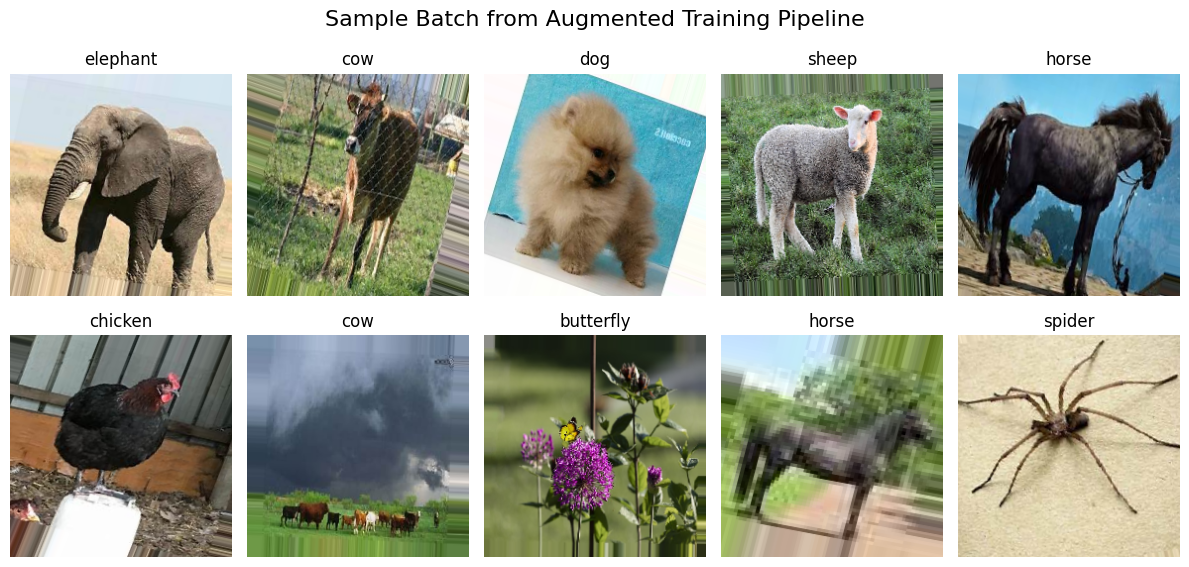

In [ ]:
# Extract one batch
imgs, labels = next(iter(train_gen))

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(imgs[i])

    # Get true label in English
    class_idx = np.argmax(labels[i])
    italian_label = list(train_gen.class_indices.keys())[class_idx]
    english_label = global_class_map[italian_label]

    plt.title(english_label)
    plt.axis('off')

plt.suptitle("Sample Batch from Augmented Training Pipeline", fontsize=16)
plt.tight_layout()
plt.show()